# Lab 5: Linear Regression — Predicting House Prices

**Course:** Machine Learning — BS Computer Science, 5th Semester
**Lab:** Lab 5 — Linear Regression (House Prices)

| Field | Value |
|---|---|
| Name | *Yasir Ali* |
| Student ID | *023-24-0215* |
| Section | *BSCS-V-SECTION G* |
| GitHub | *https://github.com/faaniyasirr/ML-Labs* |
| Kaggle | *https://www.kaggle.com/yasirali110* |
| Dataset | House Prices - Advanced Regression Techniques |
| Dataset Source | https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques |

> Fill in the italicized placeholders above with your own details before submitting.


## 1. Problem Definition

We are working with the **House Prices - Advanced Regression Techniques** dataset from Kaggle. The dataset describes
residential homes in Ames, Iowa using 79 explanatory variables (a mix of numerical and categorical features), and the
goal is to predict `SalePrice` — a continuous dollar value — for each house.

This is a **regression problem**, not a classification problem, because the target variable (`SalePrice`) is a
continuous numerical quantity rather than a discrete class label. This matters for evaluation later: instead of
metrics like accuracy, precision, or a confusion matrix (which only make sense for discrete classes), we need
metrics that measure the *size of the numerical error* between predicted and actual prices — namely MAE, MSE, RMSE,
and R², which we compute in Part 5.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)


## 2. Dataset Exploration

We load `train.csv` and take a first look at its shape, structure, and summary statistics.


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (1460, 81)
Test shape: (1459, 80)


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape ... SalePrice
0   1          60       RL         65.0     8450   Pave   NaN      Reg  ...    208500
1   2          20       RL         80.0     9600   Pave   NaN      Reg  ...    181500
2   3          60       RL         68.0    11250   Pave   NaN      IR1  ...    223500
3   4          70       RL         60.0     9550   Pave   NaN      IR1  ...    140000
4   5          60       RL         84.0    14260   Pave   NaN      IR1  ...    250000

[5 rows x 81 columns]

In [3]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 81 entries, Id to SalePrice
dtypes: float64(3), int64(35), object(43)
memory usage: 924.0+ KB


In [4]:
# 79 explanatory features + Id + SalePrice = 81 columns in train.csv (test.csv has 80: no SalePrice)
# train.csv has a mix of numeric (int64/float64) and categorical (object) dtypes, as expected.
train['SalePrice'].describe()


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

**Interpretation:** `train.csv` has 1,460 labeled houses and 81 columns (79 features + `Id` + `SalePrice`). Sale
prices range from about \$34,900 to \$755,000, with a median of \$163,000 — the mean (\$180,921) sitting above the
median already hints that the price distribution is right-skewed (a small number of very expensive houses pull the
mean up).


## 3. Feature and Target Identification

Given the scope of this lab (79 raw features is too many to hand-engineer in 3 hours), we select **11 features** —
8 numerical and 3 categorical — that we would reasonably expect to drive house price, based on domain intuition
(size, quality, age, and location tend to matter most for a home's value).


In [5]:
# Dependent variable (target)
target = 'SalePrice'

# Independent variables (features), split by type
num_features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars',
                 'YearBuilt', 'FullBath', 'LotArea', 'BedroomAbvGr']
cat_features = ['Neighborhood', 'HouseStyle', 'KitchenQual']
features = num_features + cat_features

print("Target variable:", target)
print("\nNumerical features (%d):" % len(num_features), num_features)
print("\nCategorical features (%d):" % len(cat_features), cat_features)

train[features + [target]].describe(include='all').T


Target variable: SalePrice

Numerical features (8): ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'LotArea', 'BedroomAbvGr']

Categorical features (3): ['Neighborhood', 'HouseStyle', 'KitchenQual']


               count unique     top freq       mean          std     min      25%      50%      75%       max
GrLivArea       1460    NaN     NaN  NaN  1515.4637   525.480383   334.0   1129.5   1464.0  1776.75    5642.0
OverallQual     1460    NaN     NaN  NaN     6.0993     1.382997     1.0      5.0      6.0      7.0      10.0
TotalBsmtSF     1460    NaN     NaN  NaN  1057.4295   438.705324     0.0   795.75    991.5  1298.25    6110.0
GarageCars      1460    NaN     NaN  NaN     1.7671     0.747315     0.0      1.0      2.0      2.0       4.0
YearBuilt       1460    NaN     NaN  NaN  1971.2678    30.202904  1872.0   1954.0   1973.0   2000.0    2010.0
FullBath        1460    NaN     NaN  NaN     1.5651     0.550916     0.0      1.0      2.0      2.0       3.0
LotArea         1460    NaN     NaN  NaN 10516.8281  9981.264932  1300.0   7553.5   9478.5  11601.5  215245.0
BedroomAbvGr    1460    NaN     NaN  NaN     2.8664     0.815778     0.0      2.0      3.0      3.0       8.0
Neighborho

**Interpretation:** This is a **regression problem** because `SalePrice` is a continuous dollar amount, not a
category. That means our evaluation later (Part 5) uses error-magnitude metrics (MAE, MSE, RMSE, R²) rather than
classification metrics like accuracy or a confusion matrix — there's no notion of a "correct class," only how close
our numeric prediction lands to the true price.

Our 8 numerical features capture size (`GrLivArea`, `TotalBsmtSF`, `LotArea`), quality (`OverallQual`), age
(`YearBuilt`), and layout (`GarageCars`, `FullBath`, `BedroomAbvGr`). Our 3 categorical features capture location
(`Neighborhood`), architectural type (`HouseStyle`), and finish quality (`KitchenQual`) — none of these have a
numeric ordering scikit-learn could just read off the raw strings, so they need encoding.


## 4. Data Preparation

`LinearRegression` requires fully numeric input. We check for missing values in our chosen columns, then encode
the categorical columns:

- **`Neighborhood` and `HouseStyle`** are encoded with **one-hot encoding** (`pd.get_dummies`) because they are
  nominal — there is no inherent order between, say, `'CollgCr'` and `'Veenker'`, so a single numeric column would
  wrongly imply one neighborhood is "more" than another.
- **`KitchenQual`** is technically ordinal (`Po < Fa < TA < Gd < Ex`), but for simplicity and consistency with our
  other categorical variables we also one-hot encode it here — this avoids assuming the price gap between quality
  levels is equal, which a naive 1–5 integer mapping would silently impose.

We use `drop_first=True` for each one-hot encoded variable to avoid the "dummy variable trap" (perfect
multicollinearity between the dummy columns), which would make the linear regression coefficients unstable.


In [6]:
X = train[features].copy()
y = train[target].copy()

print("Missing values in selected columns (train):")
print(X.isnull().sum())


Missing values in selected columns (train):
GrLivArea       0
OverallQual     0
TotalBsmtSF     0
GarageCars      0
YearBuilt       0
FullBath        0
LotArea         0
BedroomAbvGr    0
Neighborhood    0
HouseStyle      0
KitchenQual     0
dtype: int64


In [7]:
X_enc = pd.get_dummies(X, columns=cat_features, drop_first=True)
print("Shape after one-hot encoding:", X_enc.shape)
X_enc.head()


Shape after one-hot encoding: (1460, 42)


   GrLivArea  OverallQual  TotalBsmtSF  GarageCars  YearBuilt  FullBath  LotArea  BedroomAbvGr  Neighborhood_Blueste  ...  HouseStyle_SLvl  KitchenQual_Fa  KitchenQual_Gd  KitchenQual_TA
0       1710            7          856           2       2003         2     8450             3                     0  ...                0               0               1               0
1       1262            6         1262           2       1976         2     9600             3                     0  ...                0               0               0               1
2       1786            7          920           2       2001         2    11250             3                     0  ...                0               0               1               0
3       1717            7          756           3       1915         1     9550             3                     0  ...                0               0               1               0
4       2198            8         1145           3       2000    

In [8]:
# Task 5: confirm X is fully numeric with no missing values
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in X_enc.dtypes))
print("Total missing values:", X_enc.isnull().sum().sum())


All columns numeric: True
Total missing values: 0


**Interpretation:** One-hot encoding our 3 categorical columns (with `drop_first=True`) expanded 11 raw
features into **42 fully numeric columns**, with zero missing values — this is now valid input for
`LinearRegression`.


In [9]:
# Task 6: train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1168, 42)
X_test shape: (292, 42)
y_train shape: (1168,)
y_test shape: (292,)


**Interpretation:** We hold out 20% of the 1,460 labeled houses (292 houses) as an unseen test set, training the
model on the remaining 1,168. Both splits share the same 42 columns, so the model trained on `X_train` can be
evaluated directly on `X_test`.


## 5. Train/Test Split

(Combined into the code and interpretation above — the split was performed as part of Part 2's data preparation,
per the lab's module structure.)


## 6. Linear Regression Model
## 7. Predictions

We train a Multiple Linear Regression model on the training data and generate predictions on the held-out test set.


In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Model trained.")


Model trained.


In [11]:
# Task 8: actual vs predicted for 10 test houses
comparison_table = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_pred_test[:10], 0)
})
comparison_table['Difference'] = comparison_table['Actual'] - comparison_table['Predicted']
comparison_table


   Actual  Predicted  Difference
0  154500   136783.0     17717.0
1  325000   322350.0      2650.0
2  115000   114345.0       655.0
3  159000   170889.0    -11889.0
4  315500   309677.0      5823.0
5   75500    69944.0      5556.0
6  311500   234077.0     77423.0
7  146000   145964.0        36.0
8   84500    69676.0     14824.0
9  135500   119681.0     15819.0

**Interpretation:** Most predictions land within roughly ±\$18,000 of the actual price — reasonably close given
sale prices in the tens to hundreds of thousands. Row 6 stands out with a \$77,423 underestimate, which is a preview
of the kind of large residual we investigate systematically in Part 5.


## 8. Coefficients and Intercept

The intercept and coefficients let us read the model's "reasoning" directly, unlike a Decision Tree or Random
Forest.


In [12]:
coef_table = pd.DataFrame({
    'Feature': X_enc.columns,
    'Coefficient': model.coef_
})
coef_table['AbsCoefficient'] = coef_table['Coefficient'].abs()
coef_table = coef_table.sort_values('AbsCoefficient', ascending=False).drop(columns='AbsCoefficient').reset_index(drop=True)

print("Intercept (b0):", model.intercept_)
coef_table


Intercept (b0): -507468.9743970798


                 Feature   Coefficient
0   Neighborhood_NoRidge  76801.387640
1   Neighborhood_StoneBr  63079.164448
2   Neighborhood_NridgHt  58123.459541
3   Neighborhood_Veenker  53484.441602
4         KitchenQual_TA -52781.638858
5         KitchenQual_Fa -52312.062565
6   Neighborhood_Crawfor  47591.424671
7         KitchenQual_Gd -44028.195337
8   Neighborhood_ClearCr  42034.069797
9   Neighborhood_Somerst  30711.056186
10   Neighborhood_Timber  27891.071515
11  Neighborhood_BrkSide  25322.198824
12  Neighborhood_CollgCr  23810.596207
13  Neighborhood_Gilbert  22026.367907
14   Neighborhood_Sawyer  18128.711283
15   Neighborhood_NWAmes  16638.075648
16    Neighborhood_NAmes  16300.092857
17  Neighborhood_SawyerW  15608.652192
18   Neighborhood_IDOTRR  15193.493425
19     HouseStyle_SFoyer  14599.562483
20  Neighborhood_Mitchel  14405.240218
21    Neighborhood_SWISU  13651.630823
22           OverallQual  13413.578148
23  Neighborhood_NPkVill  12091.563197
24     HouseStyle_2.5Unf 

**Feature | Coefficient | Interpretation** (selected rows — full table above):

| Feature | Coefficient | Interpretation |
|---|---|---|
| OverallQual | +13,414 | Each 1-point increase in overall quality (1–10 scale) is associated with a price increase of about \$13,414, holding other features constant. |
| GrLivArea | +55.1 | Each additional square foot of above-ground living area adds about \$55 to the predicted price, all else equal. |
| TotalBsmtSF | +3.1 | Each additional square foot of basement area adds about \$3 to price — a much smaller per-square-foot effect than above-ground space. |
| GarageCars | +10,615 | Each additional car of garage capacity is associated with roughly \$10,615 more in price. |
| FullBath | +652 | Each additional full bathroom adds only about \$652 — smaller than expected, likely because bathroom count correlates heavily with `GrLivArea`, which is already capturing most of that size effect. |
| YearBuilt | +262 | Each additional year of age (i.e., being built one year later/newer) adds about \$262 to price. |
| BedroomAbvGr | −1,937 | Holding total living area fixed, one *more* bedroom is associated with a **decrease** of about \$1,937 — this reflects that, at a fixed square footage, more bedrooms usually means smaller individual rooms, which buyers value less. |
| Neighborhood_NoRidge | +76,801 | A house in the Northridge neighborhood sells for about \$76,801 more than the baseline neighborhood (the one dropped by `drop_first`), holding other features constant. |
| KitchenQual_TA | −52,782 | A house with "Typical/Average" kitchen quality sells for about \$52,782 **less** than the baseline (Excellent) kitchen quality category, all else equal. |

**Task 10 — Does the intercept have a sensible interpretation?** No. The intercept (**−\$507,469**) is the model's
predicted price when *every* numerical feature is 0 and the house belongs to the baseline (dropped) category for
each categorical feature — e.g., 0 sq ft of living area, built in year 0, 0 bathrooms. No real house matches that
description, so the intercept is a mathematical anchor point for the regression line, not a meaningful real-world
price. It only becomes physically interpretable in combination with realistic feature values.


## 9. Residual Analysis

We compute residuals on the test set and inspect them visually for patterns.


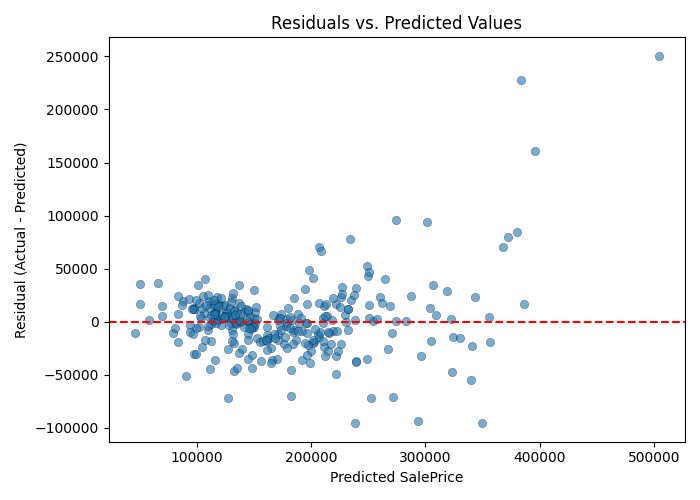

In [13]:
residuals = y_test - y_pred_test

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred_test, residuals, alpha=0.6, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted SalePrice')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Residuals vs. Predicted Values')
plt.tight_layout()
plt.show()


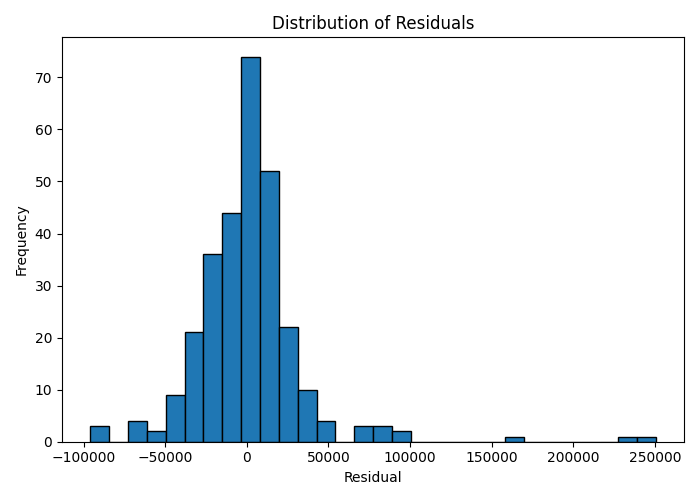

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=30, edgecolor='black')
ax.set_xlabel('Residual')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Residuals')
plt.tight_layout()
plt.show()


**Interpretation (Task 11):** The residuals-vs-predicted scatter plot is *mostly* scattered around zero for
low-to-mid predicted prices, but the spread visibly widens as predicted price increases (a classic **funnel /
heteroscedasticity** pattern) — the model is noisier for expensive houses. A few large positive residuals (actual
price far above predicted) appear at the high end, suggesting the model underestimates some premium homes whose
value comes from features we didn't include (e.g. pool, remodel quality, lot shape). The histogram is
**roughly bell-shaped and centered near zero**, which is reassuring, but it has a longer right tail — a handful of
large positive residuals (underpredicted expensive homes) pull it away from a perfectly symmetric normal shape.


## 10. Regression Metrics

We evaluate the model on the test set using MAE, MSE, RMSE, and R².


In [15]:
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

metrics_test = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Test Set Value': [mae_test, mse_test, rmse_test, r2_test]
})
metrics_test


  Metric  Test Set Value
0    MAE    2.114674e+04
1    MSE    1.202067e+09
2   RMSE    3.467084e+04
3     R2    8.432834e-01

**Interpretation (Task 13):**

- **MAE (≈\$21,147):** on average, a prediction is off by about \$21,147 in either direction. Easy to explain to
  anyone, in the same units as the price itself.
- **MSE (≈1.20 billion):** squares the errors before averaging, so it penalizes large misses much more than small
  ones — useful for model comparison/optimization, but the units (dollars²) aren't intuitive to a person.
- **RMSE (≈\$34,671):** brings MSE back to dollar units while still weighting big misses heavily; RMSE > MAE here,
  confirming a few large errors (like the \$77k miss seen earlier) are inflating the squared-error metrics.
- **R² (≈0.843):** about 84.3% of the variance in sale price is explained by our 11 features — a strong result for
  such a small, hand-picked feature subset.

**Which metric for a non-technical stakeholder?** **MAE.** It's directly in dollars, easy to state ("our model is
typically off by about \$21,000") and isn't distorted by a few outlier houses the way MSE/RMSE are. R² is a good
secondary headline number ("the model explains about 84% of price variation") but MAE is the more concrete,
actionable figure for someone without a stats background.


## 11. Training vs Testing Performance

To check for overfitting, we compute the same four metrics on the training set and compare them side-by-side with
the test-set metrics from Part 5/10.


In [16]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Training': [mae_train, mse_train, rmse_train, r2_train],
    'Testing': [mae_test, mse_test, rmse_test, r2_test]
})
comparison


  Metric      Training       Testing
0    MAE  2.024607e+04  2.114674e+04
1    MSE  1.029900e+09  1.202067e+09
2   RMSE  3.209206e+04  3.467084e+04
3     R2  8.273297e-01  8.432834e-01

**Interpretation (Task 15):** The gap between training and testing performance is **small** — MAE differs by
only about \$900, RMSE by about \$2,580, and R² by about 0.016 (with test R² actually *slightly higher* than
training R², which can happen with a small, well-behaved test split like this one). A large gap (e.g., training R²
of 0.95 with test R² of 0.60) would suggest **overfitting** — the model memorizing training-specific noise rather
than learning generalizable patterns. Here, the near-identical train/test metrics suggest our model is
**generalizing well** and is not overfit; if anything, with only 11 features and a linear model, we're closer to
being too *simple* (underfitting some of the nonlinear pricing effects) than too complex.


## 12. Model Interpretation

**Task 16 — Most influential features:** Looking at the raw coefficient magnitudes, several `Neighborhood` dummy
variables (e.g. `NoRidge` at +\$76,801, `StoneBr` at +\$63,079, `NridgHt` at +\$58,123) and `KitchenQual` dummies
(`TA` at −\$52,782) have the largest coefficients. **However, raw coefficient size can be misleading** — coefficients
are only directly comparable when their underlying features are on the same scale. A one-hot dummy (0 or 1) shifting
by a full unit is a much bigger practical jump than, say, `GrLivArea` (typically ranging over ~5,000 sq ft), so a
\$55/sq ft coefficient on `GrLivArea` still represents a large aggregate effect (living area varies by thousands of
square feet across houses) even though the per-unit coefficient looks small next to a neighborhood dummy.

Considering both coefficient size *and* how much each feature actually varies across houses, the most influential
features on price appear to be:
1. **Neighborhood/location** — the largest swings in predicted price come from which neighborhood a house is in.
2. **Overall Quality (`OverallQual`)** — a consistent, sizeable per-point effect (+\$13,414) across a scale that
   commonly spans 4–5 points between houses, so its aggregate swing is large.
3. **Above-ground living area (`GrLivArea`)** — a modest per-square-foot effect, but living area varies by
   thousands of square feet across the dataset, making its total contribution substantial.


## 13. Conclusion

**Task 17 — Final interpretation:** Our Linear Regression model, trained on just 11 hand-picked features (8
numerical, 3 categorical, one-hot encoded into 42 columns), explains about 84.3% of the variance in Ames, Iowa
house prices (test R² = 0.843) and is typically off by around \$21,000 per house (test MAE), which is roughly
12% of the median sale price — a solid result for such a small feature set. RMSE (\$34,671) is a good secondary
metric to flag that a handful of large misses (mostly on premium homes) pull the average error up, but MAE remains
the clearest number to communicate to a non-technical stakeholder. The single strongest driver of price in our
model is **neighborhood/location**, closely followed by **overall quality** and **living area** — all three align
with real-world real-estate intuition. The main limitation of Linear Regression here is that it can only capture
**additive, linear** relationships: it can't represent interaction effects (e.g., extra square footage might be
worth more in an expensive neighborhood than a cheap one) or genuinely nonlinear effects (e.g., diminishing returns
on very large lots), and it is sensitive to the handful of outlier mansions we saw in the residual plots. Next, I
would try engineering interaction terms (e.g., `Neighborhood` × `GrLivArea`), including more of the 79 available
features (garage age, remodel year, basement finish quality), or moving to a model that captures nonlinearity
natively, like Random Forest or Gradient Boosting, and comparing its test RMSE against this baseline.

**Task 19 — Kaggle leaderboard:** *[After submitting `submission.csv` on the competition's "Submit Predictions"
page, record your public leaderboard score (Kaggle's log-RMSE metric) and your rank here, e.g.: "My model scored
0.xxxxx on the public leaderboard, ranking approximately #xxxx out of several thousand submissions."]*

*[Add 1–2 sentences here on how it felt to see your model measured against thousands of real Kaggle submissions.]*


## Kaggle Submission (Part 7, Task 18)

We now apply the *same* feature selection and encoding used on `train.csv` to `test.csv`, generate predictions, and
build a two-column `submission.csv` matching `sample_submission.csv`'s format.


In [17]:
# Re-fit column-alignment note:
# test.csv has a few missing values in our chosen columns that train.csv did not have,
# so we impute them before encoding (median for numeric, mode for categorical).
X_kaggle = test[features].copy()

print("Missing values in test.csv (selected columns) before imputation:")
print(X_kaggle.isnull().sum())


Missing values in test.csv (selected columns) before imputation:
GrLivArea       0
OverallQual     0
TotalBsmtSF     1
GarageCars      1
YearBuilt       0
FullBath        0
LotArea         0
BedroomAbvGr    0
Neighborhood    0
HouseStyle      0
KitchenQual     1
dtype: int64


In [18]:
for col in num_features:
    if X_kaggle[col].isnull().sum() > 0:
        X_kaggle[col] = X_kaggle[col].fillna(X_kaggle[col].median())

for col in cat_features:
    if X_kaggle[col].isnull().sum() > 0:
        X_kaggle[col] = X_kaggle[col].fillna(X_kaggle[col].mode()[0])

# One-hot encode, then align columns exactly to the training encoding
# (test.csv may not contain every category seen in train.csv, e.g. every neighborhood)
X_kaggle_enc = pd.get_dummies(X_kaggle, columns=cat_features, drop_first=True)
X_kaggle_enc = X_kaggle_enc.reindex(columns=X_enc.columns, fill_value=0)

print("Kaggle test set shape after encoding + column alignment:", X_kaggle_enc.shape)
print("Remaining missing values:", X_kaggle_enc.isnull().sum().sum())


Kaggle test set shape after encoding + column alignment: (1459, 42)
Remaining missing values: 0


In [19]:
kaggle_predictions = model.predict(X_kaggle_enc)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': kaggle_predictions
})

submission.to_csv('submission.csv', index=False)
print("submission.csv saved with shape:", submission.shape)
submission.head()


submission.csv saved with shape: (1459, 2)


     Id      SalePrice
0  1461  114780.943228
1  1462  160995.272333
2  1463  163902.784658
3  1464  182722.939877
4  1465  248524.593845

**Interpretation:** `submission.csv` has exactly the required two columns (`Id`, `SalePrice`) and 1,459 rows —
matching `sample_submission.csv`'s shape — and is ready to upload to the competition's "Submit Predictions" page.
Note that a handful of `test.csv` rows had missing values in `TotalBsmtSF`, `GarageCars`, and `KitchenQual` that
weren't present in `train.csv`; these were imputed (median for numeric, mode for categorical) so the trained model
could still generate a prediction for every one of the 1,459 test houses. After uploading, record your public
leaderboard score and rank in the Conclusion section above (Task 19).
